<a href="https://colab.research.google.com/github/isamagana/microeconometria/blob/main/Tarea1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tarea 1**
**Isabela Magaña**

**Población, muestra e identificación**

**Pregunta 1: Define claramente la población efectivamente representada por
la base. ¿Los resultados pueden generalizarse a las viviendas de Windsor en general?**

La población efectivamente representada por la base son los residenciales de compraventa de Windsor de los últimos 3 meses, de aquí sale la muestra aleatoria de las 546 operaciones.
Los resultados NO pueden generalizarse a las viviendas de Windsor porque en la muestra se excluyen a las viviendas que no estaban verificadas ni en las fichas inmobiliarias como en los registros municipales.

**Pregunta 2: Juzga cuáles de estas estrategias permiten producir una muestra i.i.d. En cada caso, indica cuál(es)
de estas propiedades se pierde(n) y por qué. No necesitas hacer una demostración, solo argumentar
la problemática que puede existir.**

Todas estas opciones del intern no son buenas.
Opción 1: Aquí no existiria independencia porque se agrupan las observaciones dependiendo del barrio y normalmente el barrio está correlacionado con factores como el nivel socioeconómico y otros factores que pueden afectar a que las observaciones igual estén correlacinadas. Igual, es sumamente improbable que los barrios tengan la misma distribución.

Opción 2: en esta opción no existe la independencia, ya que la primera agenda podría tener nexos o conflictos de interés con la segunda, el análisis de la segunda empresa dependio enteramente en el simple hecho que se haya elegido contratar a la primera agencia y existe un sesgo de selección.

Opción 3: aquí igual se viola la independencia porque al elegir la primera observación se determina el outcome de las siguientes porque es sitemático y no aleatorio con la misma probabilidad, aquí el orden si afecta.



**Pregunta 3: tabla de estadística descriptiva y su utilidad**

In [2]:
from google.colab import files

uploaded = files.upload()

Saving hp.csv to hp.csv


In [3]:
import pandas as pd

df = pd.read_csv("hp.csv")

variables = [
    "price", "lotsize", "bedrooms", "bathrooms",
    "stories", "garage", "driveway", "recreation",
    "fullbase", "gasheat", "aircon", "prefer"
]

categoricas = [
    "driveway", "recreation", "fullbase",
    "gasheat", "aircon", "prefer"
]

for var in categoricas:
    df[var] = df[var].map({"yes": 1, "no": 0})

tabla_descriptiva = pd.DataFrame({
    "numero": df[variables].count(),
    "media": df[variables].mean(),
    "varianza": df[variables].var(),
    "desviacion estandar": df[variables].std(),
    "min": df[variables].min(),
    "max": df[variables].max()
})

tabla_descriptiva.index = [
    var + "*" if var in categoricas else var
    for var in tabla_descriptiva.index
]

tabla_descriptiva = tabla_descriptiva.round(2)

print(tabla_descriptiva)

             numero     media      varianza  desviacion estandar    min  \
price           546  68121.60  7.130326e+08             26702.67  25000   
lotsize         546   5150.27  4.700912e+06              2168.16   1650   
bedrooms        546      2.97  5.400000e-01                 0.74      1   
bathrooms       546      1.29  2.500000e-01                 0.50      1   
stories         546      1.81  7.500000e-01                 0.87      1   
garage          546      0.69  7.400000e-01                 0.86      0   
driveway*       546      0.86  1.200000e-01                 0.35      0   
recreation*     546      0.18  1.500000e-01                 0.38      0   
fullbase*       546      0.35  2.300000e-01                 0.48      0   
gasheat*        546      0.05  4.000000e-02                 0.21      0   
aircon*         546      0.32  2.200000e-01                 0.47      0   
prefer*         546      0.23  1.800000e-01                 0.42      0   

                max  
pr

Esta tabla es útil porque nos ayuda a visualizar los datos antes de analizarlos como tal, nos ayuda a conocer un poco de cómo se comportan.

Al tener las variables categoricas como dummy, podemos ver sus estadísticos como la media como una proporción. O sea la media aquí indica la proporción de viviendas que tienen dicha caracteristica.

Pregunta 4: Histograma con variable price SIN ln

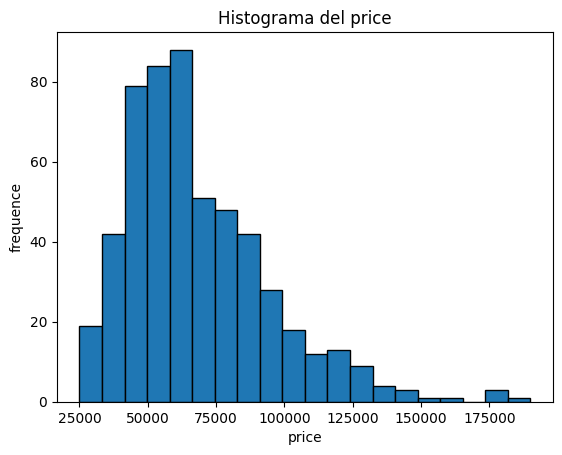

In [4]:
import matplotlib.pyplot as plt

plt.hist(df["price"], bins=20, edgecolor="black")

plt.xlabel("price")
plt.ylabel("frequence")
plt.title("Histograma del price")

plt.show()

Histograma variable price CON ln



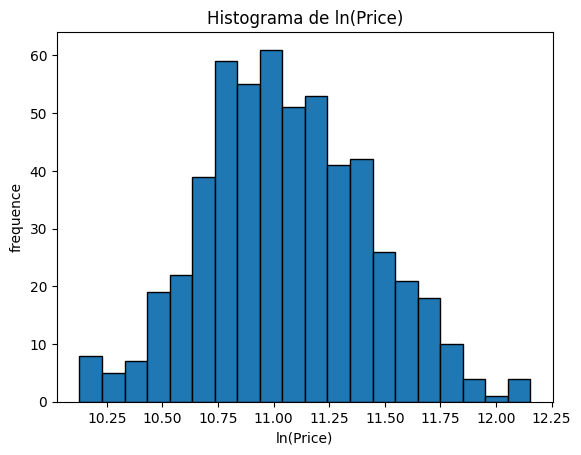

In [5]:
import numpy as np
import matplotlib.pyplot as plt

df["ln_price"] = np.log(df["price"])

plt.hist(df["ln_price"], bins=20, edgecolor="black")

plt.xlabel("ln(Price)")
plt.ylabel("frequence")
plt.title("Histograma de ln(Price)")

plt.show()

Pregunta 5: Scatterplot

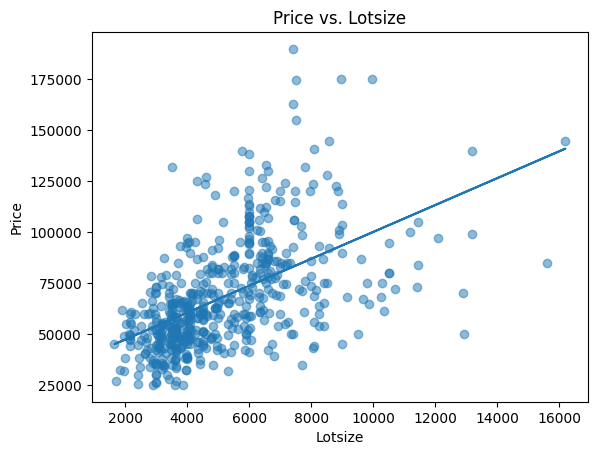

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(df["lotsize"], df["price"], alpha=0.5)

b1, b0 = np.polyfit(df["lotsize"], df["price"], 1)

plt.plot(
    df["lotsize"],
    b0 + b1 * df["lotsize"]
)

plt.xlabel("Lotsize")
plt.ylabel("Price")
plt.title("Price vs. Lotsize")

plt.show()

Existe una relación positiva entre el precio y el lotsize, lo cual indica que las viviendas con lotes más grandes tienen un precio más alto. Esto se ve muy claro al principio, pero después observamos que la dispersión de los datos crece conforme aumenta el lotsize. Con esto podemos ver que si se puede aproximar linealmente la recta de regresión.

Pregunta 6: regresión no parametrica  KERNEL CON UN BANDWITH GRANDE.

/usr/local/lib/python3.13/dist-packages/pandas/util/_decorators.py:213: FutureWarning: After 0.17 or January 2028, whichever comes first, the default behavior will switch to using an entropy initialized numpy.random.Generator.
  return func(*args, **kwargs)


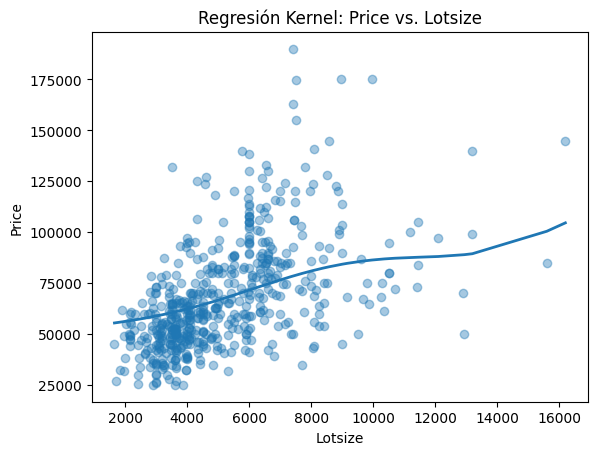

In [7]:
from statsmodels.nonparametric.kernel_regression import KernelReg
import numpy as np
import matplotlib.pyplot as plt

x = df["lotsize"].values
y = df["price"].values

orden = np.argsort(x)
x_ordenado = x[orden]

kernel = KernelReg(
    endog=y,
    exog=x,
    var_type="c",
    reg_type="lc",
    bw=[2000]
)

y_kernel, _ = kernel.fit(x_ordenado)

plt.scatter(x, y, alpha=0.4)
plt.plot(x_ordenado, y_kernel, linewidth=2)

plt.xlabel("Lotsize")
plt.ylabel("Price")
plt.title("Regresión Kernel: Price vs. Lotsize")
plt.show()

Se eligió usar Kernel y no impuse una forma funcional específica con un bandwith "grande" para suavizar la curva, ya que no queremos que afecte mucho el ruido y la impresición y use lotsize como variable continua.

In [8]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

df = pd.read_csv("hp.csv")

categoricas = [
    "driveway", "recreation", "fullbase",
    "gasheat", "aircon", "prefer"
]

for var in categoricas:
    df[var] = df[var].map({"yes": 1, "no": 0})

df["ln_price"] = np.log(df["price"])
df["ln_lotsize"] = np.log(df["lotsize"])

**Regresión, especificación e interpretación**

**Pregunta 7: estimar 5 especificaciones de la tabla**

In [9]:
import numpy as np
import statsmodels.formula.api as smf

df["ln_price"] = np.log(df["price"])
df["ln_lotsize"] = np.log(df["lotsize"])

In [10]:
modelo1 = smf.ols(
    "price ~ lotsize",
    data=df
).fit(cov_type="HC1")


modelo2 = smf.ols(
    "ln_price ~ lotsize",
    data=df
).fit(cov_type="HC1")


modelo3 = smf.ols(
    "price ~ ln_lotsize + bedrooms + bathrooms",
    data=df
).fit(cov_type="HC1")


modelo4 = smf.ols(
    "ln_price ~ ln_lotsize + bedrooms + bathrooms + stories",
    data=df
).fit(cov_type="HC1")


modelo5 = smf.ols(
    "ln_price ~ ln_lotsize + bedrooms + bathrooms + stories + driveway + aircon + garage + prefer",
    data=df
).fit(cov_type="HC1")

In [11]:
print(modelo1.summary())
print(modelo2.summary())
print(modelo3.summary())
print(modelo4.summary())
print(modelo5.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     130.8
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           2.72e-27
Time:                        21:45:47   Log-Likelihood:                -6247.0
No. Observations:                 546   AIC:                         1.250e+04
Df Residuals:                     544   BIC:                         1.251e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3.414e+04   2646.273     12.900      0.0

**Pregunta 8: Da una interpretación lo más específica posible utilizando las unidades correctas para los valores estimados de los siguientes coeficientes. En esta pregunta concéntrate en el significado de los valores estimados sin prestar atención en su significancia estadística.**

In [12]:
print("8a lotsize modelo 1:", modelo1.params["lotsize"])
print("8b lotsize modelo 2:", modelo2.params["lotsize"])
print("8c ln(lotsize) modelo 3:", modelo3.params["ln_lotsize"])
print("8d ln(lotsize) modelo 4:", modelo4.params["ln_lotsize"])
print("8e bathrooms modelo 3:", modelo3.params["bathrooms"])
print("8f aircon modelo 5:", modelo5.params["aircon"])
print("8g beta0 modelo 1:", modelo1.params["Intercept"])

8a lotsize modelo 1: 6.598767589265608
8b lotsize modelo 2: 9.314505200674164e-05
8c ln(lotsize) modelo 3: 31106.490370235424
8d ln(lotsize) modelo 4: 0.45273664830476634
8e bathrooms modelo 3: 19284.662576771676
8f aircon modelo 5: 0.1654543085436635
8g beta0 modelo 1: 34136.191564915076


8a. Indica que con cada aumento de 1 pie² en el lote, el aumento esperado será de $6.60 en el precio.

8b. Indica que con cada aumento de 1 pie² en el lote, el aumento esperado será de aproximadamente 0.0093% en el precio.

8c. Indica que con cada aumento de 1% en el tamaño del lote, el aumento esperado será de aproximadamente $311.06 en el precio, manteniendo constantes las demás variables del modelo.

8d. Indica que con cada aumento de 1% en el tamaño del lote, el aumento esperado será de aproximadamente 0.453% en el precio, manteniendo constantes las demás variables del modelo.

8e. Indica que con cada baño completo adicional, el aumento esperado será de aproximadamente $19,284.66 en el precio, ceteris paribus las demás variables.

8f. Indica que una vivienda con aire acondicionado central tendrá un precio esperado aproximadamente 18.0% mayor que una vivienda sin aire acondicionado central, ceteris paribus las demás variables.

8g. Indica que cuando el tamaño del lote es igual a 0 pies², el precio esperado será de $34,136.19. Lo cual suena ilógico.


**Pregunta 9: Analiza si la magnitud de los coeficientes asociados a lotsize en la especificación (1) y a aircon en
la especificación (5) es grande o pequeña. Elige y explica los puntos de comparación que utilizarás
para sustentar tu respuesta.**

In [13]:
efecto_lotsize = modelo1.params["lotsize"] * df["lotsize"].std()
efecto_lotsize

np.float64(14307.175524421638)

Ahora comparando con el precio promedio


In [14]:
porcentaje_precio_promedio = efecto_lotsize / df["price"].mean() * 100
porcentaje_precio_promedio

np.float64(21.002407664935653)

Para comparar se uso un aumento de la desviación estándar en el lotsize que resulta en promedio un incremento de 14,307 en el precio de la vivienda, lo cual corresponde a un 21% del precio esperado de las viviendas muestrales.

Ahora con aircon...

In [16]:
efecto_aircon = (np.exp(modelo5.params["aircon"]) - 1) * 100
efecto_aircon

np.float64(17.99290488111529)

Para evaluar la magnitud del coeficiente de aircon, comparamos una vivienda sin aire acondicionado frente a una vivienda con aire acondicionado (porque aircon es una variable dummy). De acuerdo con la especificación, tener aire acondicionado se asocia con un precio esperado aprox 18% más alto (ceteris paribus).

**Pregunta 10: Un analista sostiene que la relación entre el tamaño del lote y el precio podría ser distinta para las
viviendas ubicadas en una zona preferida. Propón una sola ecuación, basada en la especificación
(5) que permita evaluar esta afirmación.
a) Escribe la ecuación, identifica el coeficiente relevante y calcula la elasticidad estimada del
precio respecto al tamaño del lote para una vivienda fuera de la zona preferida y para una
vivienda dentro de ella.
b) Construye intervalos de confianza de 90% para ambas elasticidades y evalúa al 5% de significancia si son estadísticamente distintas.**

In [17]:
modelo10 = smf.ols(
    "ln_price ~ ln_lotsize * prefer + bedrooms + bathrooms + stories + driveway + aircon + garage",
    data=df
).fit(cov_type="HC1")

print(modelo10.summary())

                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.652
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     132.1
Date:                Fri, 02 Oct 2026   Prob (F-statistic):          7.14e-130
Time:                        22:06:51   Log-Likelihood:                 54.140
No. Observations:                 546   AIC:                            -88.28
Df Residuals:                     536   BIC:                            -45.25
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             7.8063      0.28

In [18]:
elasticidad_no_prefer = modelo10.params["ln_lotsize"]

elasticidad_prefer = (
    modelo10.params["ln_lotsize"]
    + modelo10.params["ln_lotsize:prefer"]
)

print("Elasticidad fuera de zona preferida:", elasticidad_no_prefer)
print("Elasticidad dentro de zona preferida:", elasticidad_prefer)

Elasticidad fuera de zona preferida: 0.29638277889596953
Elasticidad dentro de zona preferida: 0.31478518622635376


In [19]:
from scipy.stats import norm
import numpy as np

# IC
z = norm.ppf(0.95)

b1 = modelo10.params["ln_lotsize"]
se_b1 = modelo10.bse["ln_lotsize"]

IC_no_prefer = (
    b1 - z * se_b1,
    b1 + z * se_b1
)

cov = modelo10.cov_params()

var_prefer = (
    cov.loc["ln_lotsize", "ln_lotsize"]
    + cov.loc["ln_lotsize:prefer", "ln_lotsize:prefer"]
    + 2 * cov.loc["ln_lotsize", "ln_lotsize:prefer"]
)

se_prefer = np.sqrt(var_prefer)

IC_prefer = (
    elasticidad_prefer - z * se_prefer,
    elasticidad_prefer + z * se_prefer
)

print("IC 90% fuera de zona preferida:", IC_no_prefer)
print("IC 90% dentro de zona preferida:", IC_prefer)


IC 90% fuera de zona preferida: (np.float64(0.23706036683217233), np.float64(0.3557051909597667))
IC 90% dentro de zona preferida: (np.float64(0.255669840574321), np.float64(0.3739005318783865))


In [20]:
p_value = modelo10.pvalues["ln_lotsize:prefer"]
print(p_value)

0.7082944182542306


El p value obtenido es 0.708 y es mayor a 0.05, por lo tanto no se rechaza la hipótesis nula. Con un nivel de confianza del 90% podemos afirmar que no existe evidencia estadística de que las elasticidades sean distintas entre viviendas dentro y fuera de la zona preferida.

**Pregunta 11: a) Obtén la predicción del precio para una vivienda con estas características [ojo: de precio, no
de log (precio)].
b) Mediante un bootstrap de 1,000 repeticiones, grafica la distribución empírica de esa predicción
y construye un intervalo de confianza del 93%.
c) Existe una manera analítica de obtener un intervalo de confianza para el precio con los resultados de la estimación de MCO. Llévalo a cabo y compara dicha estimación contra el resultado
de bootstrap.**

In [21]:
nueva_casa = pd.DataFrame({
    "ln_lotsize": [np.log(6000)],
    "bedrooms": [3],
    "bathrooms": [2],
    "stories": [2],
    "driveway": [1],
    "aircon": [1],
    "garage": [1],
    "prefer": [1]
})

pred_log = modelo5.predict(nueva_casa)[0]
pred_price = np.exp(pred_log)

print("prediccion ln(price):", pred_log)
print("Prediccion price:", pred_price)

Predicción ln(price): 11.545637899822834
Predicción price: 103325.33688581195


In [22]:
# inciso b
predicciones_bootstrap = []

np.random.seed(123)

for i in range(1000):

    muestra = df.sample(
        n=len(df),
        replace=True
    )

    modelo_boot = smf.ols(
        "ln_price ~ ln_lotsize + bedrooms + bathrooms + stories + driveway + aircon + garage + prefer",
        data=muestra
    ).fit()

    pred_log_boot = modelo_boot.predict(nueva_casa)[0]
    pred_price_boot = np.exp(pred_log_boot)

    predicciones_bootstrap.append(pred_price_boot)

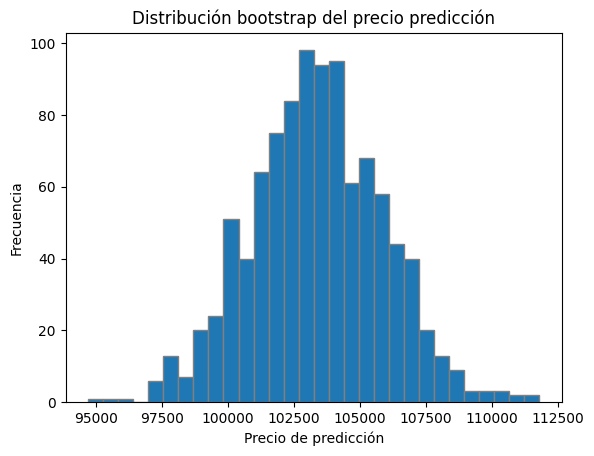

In [23]:
import matplotlib.pyplot as plt

plt.hist(
    predicciones_bootstrap,
    bins=30,
    edgecolor="gray"
)

plt.xlabel("Precio de predicción")
plt.ylabel("Frecuencia")
plt.title("Distribución bootstrap del precio predicción")
plt.show()

In [24]:
from scipy.stats import norm
import numpy as np

z = norm.ppf(0.965)
print(z)

1.8119106729525973


In [26]:
from scipy.stats import norm
import numpy as np

prediccion_analitica = modelo5.get_prediction(nueva_casa)

pred_log = prediccion_analitica.predicted_mean[0]

se_log = prediccion_analitica.se_mean[0]

alpha = 1 - 0.93
z = norm.ppf(1 - alpha/2)

LI_log = pred_log - z * se_log
LS_log = pred_log + z * se_log

LI_price = np.exp(LI_log)
LS_price = np.exp(LS_log)

print("Predicción:", np.exp(pred_log))
print("Error estándar:", se_log)
print("z crítico:", z)
print("IC analítico 93%:", (LI_price, LS_price))

Predicción: 103325.33688581195
Error estándar: 0.023765091838703047
z crítico: 1.8119106729525989
IC analítico 93%: (np.float64(98970.55654806264), np.float64(107871.73089586428))


Con un nivel de confianza del 93% la predicción del precio es de [$98,971, $107,872]. Al compararlo con el intervalo del bootstrap, ambos son muy similares, por lo que los dos métodos llevan a una conclusión consistente.

In [27]:
#nuevo modelo
modelo12 = smf.ols(
    "ln_price ~ lotsize + ln_lotsize + bedrooms + bathrooms + stories + driveway + aircon + garage + prefer",
    data=df
).fit(cov_type="HC1")

print(modelo12.summary())

                            OLS Regression Results                            
Dep. Variable:               ln_price   R-squared:                       0.653
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     132.6
Date:                Fri, 02 Oct 2026   Prob (F-statistic):          3.37e-130
Time:                        22:27:39   Log-Likelihood:                 54.835
No. Observations:                 546   AIC:                            -89.67
Df Residuals:                     536   BIC:                            -46.64
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.9452      0.681     10.205      0.0

No existe multicolinealidad perfecta entre lotsize y ln(lotsize), ya que el logaritmo de lotsize es una transformación no lineal de lotsize.

In [28]:
b_lotsize = modelo12.params["lotsize"]
b_ln_lotsize = modelo12.params["ln_lotsize"]

elasticidad_6000 = b_lotsize * 6000 + b_ln_lotsize

print("coeficiente lotsize:", b_lotsize)
print("coeficiente ln_lotsize:", b_ln_lotsize)
print("elasticidad en 6000 pies²:", elasticidad_6000)

coeficiente lotsize: -2.053185522313624e-05
coeficiente ln_lotsize: 0.4112085972239353
elasticidad en 6000 pies²: 0.2880174658851179


Para una vivienda con un lote de 6,000 pies², un aumento de 1% en el tamaño del lote implica un aumento esperado de  0.288% en el precio, ceteris paribus las otras variables.

**Pregunta 13**

La estimación de lotsize si puede estar afectado porque si las viviendas que tienen lotes más grandes también tienden a tener una mayor superficie construida y si al tener más superficie construida hace que el precio aumente, si omitimos esta variable el modelo le pasaría esa atribución a lotsize (y es un efecto que realmente corresponde a la superficie construida). Si esto pasa, significa que el coeficiente de lotsize tiene un sesgo positivo y sobreestimariamos su verdadero efecto sobre el precio.

**Pregunta 14**

El coef de lotsize puede no ser 100% veridico porque puede ser que el tamaño del lote registrado no sea el de su tamaño real. Esto puede sonar como que no ocurririía, pero simplemente pueden recurrir a redondear por comodidad por ejemplo un lote de 5889 pies podría haberse registrado como de 6000. Si estos errores ocurren seguido y aleatoriamente, registrando un valor mayor y/o  menor, se vuelve más difícil identificar la verdadera relación entre el tamaño del lote y el precio. Como consecuencia, el efecto estimado de lotsize tendería a verse más pequeño de lo que realmente es.